## Project Done By

1. Wong Kwan Kit
2. Ryan Phua Rui En

### Contributions:
1. Wong Kwan Kit
   - Research and implementation of Deep Q-Network
   - Rendering of video for Cartpole
   - Markdown
2. Ryan Phua Rui En
   - Research and implementation of Generalised Policy Iteration with Epsilon-Greedy Function
   - Markdown

### References
1. Reinforcement Learning (DQN) Tutorial (https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html)
2. Policy Iteration (https://gibberblot.github.io/rl-notes/single-agent/policy-iteration.html)
3. Generalised Policy Iteration (https://pantelis.github.io/aiml-common/lectures/reinforcement-learning/model-free-control/generalized-policy-iteration/)

## Project Description

### Catrpole Problem
A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces in the **left and right direction** on the cart.

#### 1. Action Space
The action is an ndarray with shape (1,) which can take values {0, 1} indicating pushing the cart to the left or right, respectively. The velocity that is reduced or increased by the applied force is not fixed and it depends on the angle the pole is pointing. The center of gravity of the pole varies the amount of energy needed to move the cart underneath it.

#### 2. State Space
The observation is an ndarray with shape (4,) with the values corresponding to the following positions and velocities:

| Num | Observation           | Min                     | Max                     |
|-----|-----------------------|-------------------------|-------------------------|
| 0   | Cart Position        | -4.8                    | 4.8                     |
| 1   | Cart Velocity        | -∞                      | ∞                       |
| 2   | Pole Angle          | ~ -0.418 rad (-24°)     | ~ 0.418 rad (24°)      |
| 3   | Pole Angular Velocity | -∞                      | ∞                       |



### Challenge
To develop a Reinforcement Learning (RL) agent, where the trained agent makes the decision to push the cart to the left or right based on the cart position, velocity, and the pole angle, angular velocity, in order to balance the Cartpole.


## Solution

In order to develop a RL agent, we consider two options for the algorithm implementation:
1. **Deep Q-Network** (Q-Learning)
2. **Generalised Policy Iteration** with **Epsilon-Greedy** function

## Environment Creation

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import base64
from collections import deque
from collections import defaultdict
from pathlib import Path
from IPython.display import HTML, display
from gymnasium.utils.save_video import save_video

In [2]:
env = gym.make("CartPole-v1")

In [3]:
print(env.action_space)

Discrete(2)


In [4]:
print(env.observation_space)

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


## Task 1: Development of an RL agent

## Deep Q-Network (Q-Learning)

In [5]:
# Neural network model for approximating Q-values
class DQN(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_features, 128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128, output_features)
        )
    
    def forward(self, state):
        return self.net(state)

In [6]:
# Agent for training
class DQNAgent:
    def __init__(self, env, episodes=3000, lr=0.001, gamma=0.99, epsilon_start=1.0, 
                 epsilon_min=0.01, epsilon_decay=0.995, batch_size=256, memory_size=10000,
                 target_update_freq=500):
        
        self.env = env
        self.input_features = env.observation_space.shape[0]
        self.output_features = env.action_space.n
        
        # Initialise Q-Networks
        self.policy_net = DQN(self.input_features, self.output_features)
        self.target_net = DQN(self.input_features, self.output_features)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        # Training setup
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.criterion = nn.MSELoss()
        self.memory = deque(maxlen=memory_size)
        
        # Hyperparameters
        self.episodes = episodes
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.steps_done = 0

    # Function to determine epsilon value that decays with episodes
    def get_epsilon(self, episode):
        eps_value = self.epsilon_start * (self.epsilon_decay ** episode)
        return max(self.epsilon_min, eps_value)  # Ensure it doesn't go below epsilon_end

    # Function to choose action based on an epsilon-greedy policy
    def select_action(self, state, episode):
        self.steps_done += 1
        epsilon_threshold = self.get_epsilon(episode)        
        if random.random() < epsilon_threshold:
            return self.env.action_space.sample()  # Explore
        else:
            with torch.no_grad(): # Exclude from gradient computation since it is an action step
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                return self.policy_net(state_tensor).argmax().item()  # Exploit

    # Function to store the transitions into memory
    def store_transition(self, state, action, reward, next_state):
        self.memory.append((
            torch.FloatTensor(state),
            action,
            torch.FloatTensor([reward]),
            torch.FloatTensor(next_state) if next_state is not None else None
        ))

    # Function to optimise the policy network
    def optimize_model(self):
        # Too little iterations to batch 
        if len(self.memory) < self.batch_size:
            return
        
        # Sample batch
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states = zip(*batch)
        
        # Convert to tensors
        state_batch = torch.stack(states) # shape is [256,4]
        action_batch = torch.LongTensor(actions).unsqueeze(1) # shape is [256,1]
        reward_batch = torch.cat(rewards) # shape is [256]
        
        # Predict Q-values for current states and actions taken Qpolicy(s,a)
        predicted_q_values = self.policy_net(state_batch).gather(1, action_batch) # shape is [256,1]
        
        # Compute the rewards of the future states
        next_state_values = torch.zeros(self.batch_size)
        non_final_mask = torch.tensor([s is not None for s in next_states], dtype=torch.bool)
        non_final_next_states = torch.stack([s for s in next_states if s is not None])
        
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values # shape is [256]
        
        # Compute expected Q values for current states and actions taken Qtarget(s,a)
        expected_q_values = (next_state_values * self.gamma) + reward_batch # shape is [256]
        
        # Compute loss
        loss = self.criterion(predicted_q_values, expected_q_values.unsqueeze(1))
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 10)
        self.optimizer.step()

    # Function to hard update the target network
    def update_target_network(self):
        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    # Function to train the policy network
    def train(self, print_every=100, window_size=100):
        rewards = []
        running_avg = []
        for episode in range(self.episodes):
            state, _ = self.env.reset()
            episode_reward = 0
            done = False
            
            while not done:
                action = self.select_action(state, episode)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                
                self.store_transition(state, action, reward, next_state if not terminated else None)
                self.optimize_model()
                self.update_target_network()
                
                state = next_state
                episode_reward += reward
            
            rewards.append(episode_reward)
            if episode >= window_size:
                avg = sum(rewards[-window_size:])/window_size
                running_avg.append(avg)
            else:
                avg = sum(rewards)/len(rewards)
                running_avg.append(avg)
            
            if episode % print_every == 0:
                print(f'Episode {episode} | Reward: {episode_reward} | Running Average ({window_size}): {avg:.3f}')
        
        # Plot results
        plt.figure(figsize = (16,8))
        plt.plot(rewards, label = 'Episode Reward')
        plt.plot(running_avg, label = f'Running Avg ({window_size})')
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.title('DQN Training Progress')
        plt.legend()
        plt.show()

    # Function to save the policy network state dict
    def save(self, save_dir=None, overwrite=True):
        # Use working directory if None is provided
        if save_dir is None:
            save_dir = os.getcwd()
        Path(save_dir).mkdir(parents=True, exist_ok = True)

        file_name = 'CartPole_DQN_model.pth'
        save_path = os.path.join(save_dir, file_name)

        # Save model to path
        torch.save(self.policy_net.state_dict(), save_path)

        # Verify if model is saved
        if os.path.exists(save_path):
            print(f'Model saved to: {save_path}')
        else:
            print(f'Failed to save model to: {save_path}')

    # Functon to load the saved model
    def load(self, model_path=None):
        # Use working directory if None is provided
        if model_path is None:
            model_path = os.path.join(os.getcwd(), 'CartPole_DQN_model.pth')
        
        # Check if file exists
        if os.path.exists(model_path):
            self.policy_net.load_state_dict(torch.load(model_path))
            self.target_net.load_state_dict(self.policy_net.state_dict())  # Sync target network
            print(f"Successfully loaded model from {model_path}")
        else:
            print(f"Error: Model file not found at {model_path}")

    # Function to test the policy network
    def test(self, benchmark=195):
        self.policy_net.eval() # Set to eval mode
        total_rewards = []
        for episode in range(1,101):
            state,_ = self.env.reset()
            episode_reward = 0
            done = False

            while not done:
                with torch.no_grad():
                    self.epsilon_start = 0.001 # Minimise exploration
                    action = self.select_action(state, episode)
                    next_state, reward, terminated, truncated, _ = self.env.step(action)
                    done = terminated or truncated
                    state = next_state
                    episode_reward += reward

            total_rewards.append(episode_reward)

        plt.figure(figsize = (16,8))
        plt.plot(total_rewards, label = 'Episode Reward')
        plt.axhline(benchmark, color = 'r', linestyle = '--', label = f'Benchmark: {benchmark}')
        plt.xlabel('Episode')
        plt.ylabel('Cumulative Reward')
        plt.title('DQN Test: Cumulative Reward for Each Episode')
        plt.legend()
        plt.show()
        print("Average Cumulative Reward: ", np.mean(total_rewards))
        print("Is my Agent good enough? ", np.mean(total_rewards) > benchmark)

    def render(self, vid_dir=None, fps=30, overwrite=True):
        # Use working directory if None is provided
        if vid_dir is None:
            vid_dir = os.getcwd()
        Path(vid_dir).mkdir(parents=True, exist_ok = True)

        vid_name = 'CartPole_DQN_video'

        # Setting up Video Environment
        vid_env = gym.make('CartPole-v1', render_mode = 'rgb_array_list')

        # # Run Episode
        episode = 1
        state,_ = vid_env.reset()
        self.policy_net.eval() # Set to eval mode
        done = False
        
        while not done:
            with torch.no_grad():
                self.epsilon_start = 0.001 # Minimise exploration
                action = self.select_action(state, episode)
                next_state, _, terminated, truncated, _ = vid_env.step(action)
                done = terminated or truncated
                state = next_state

        save_video(frames = vid_env.render(), video_folder = vid_dir, fps=env.metadata["render_fps"], name_prefix = vid_name)
        vid_env.close()

        # Display the video
        full_vid_name = 'CartPole_DQN_video-episode-0.mp4'
        vid_path = os.path.join(vid_dir, full_vid_name)
        self.display_video(vid_path)

    def display_video(self, vid_path):
        video = open(vid_path, 'rb').read()
        encoded = base64.b64encode(video).decode()
        display(HTML(f'<video width="600" controls><source src="data:video/mp4;base64,{encoded}"></video>'))
        

## Generalised Policy Iteration (Epsilon-Greedy)

While Policy Iteration (PI) employs classic dynamic programming with focus on solving the Bellman Equation till convergence before the policy is updated greedily, Generalised Policy Iteration (GPI) is a broader framework that generalises PI by relaxing its rigid requirements.
The classic PI algorithm uses dynamic programming, which may lead to higher calculation overhead and additional time required when running the algorithm. Hence, GPI is able to improve on this aspect.

Instead of exact convergence, the state-value function can be updated partially. Interleaved Policy Improvement can also be employed, where policy updates can happen before the state-value function fully converges. Policies can also be stochastic (e.g. epsilon-greedy) during training. This provides a more balanced evaluation and flexible improvement.

We employed Temporal Difference and Epsilon-Greedy functions to improve the classic policy iteration algorithm.

- Advantages of Temporal Difference (TD)
    - Continuous improvement: Updates $V(s)$ after every transition (no need to wait for episode completion).
    - Bootstrapping: TD combines observed rewards with current estimates (lower variance than Monte Carlo).
- Advantages of Epsilon-Greedy
    - Balanced Exploration-Exploitation: Always has at least ε probability to try random actions, preventing policy stagnation.
    - Annealing ε over time: Start with high exploration (ε ≈ 1.0), decay to low (ε ≈ 0.01):

GPI is carried out in four steps:
1. Discretize States
2. Policy Evaluation
3. Policy Improvement
4. Policy Iteration



### 1. Discretize States
As the GPI employed is in a tabular method, variables such as Cart Velocity and Pole Velocity are continuous variables $(-∞,+∞ )$ and are unable to be stored in the table as our $V(s)$ value will now be a continuous vector instead of a discrete integer.

Therefore, the continuous states must be converted into discrete bins.

In [ ]:
# State discretization ranges (official CartPole limits)
state_ranges = [
    (-4.8, 4.8),    # Cart position
    (-2.0, 2.0),    # Cart velocity
    (-0.418, 0.418),  # Pole angle
    (-2.0, 2.0)     # Pole velocity
]

In [ ]:
# Hyperparameters
gamma = 0.99          # Discount factor
theta = 1e-3          # Convergence threshold
max_iterations = 1000  # Max iterations for policy evaluation
num_actions = env.action_space.n
state_bins = [16, 16, 16, 16]
num_episodes = 3000    # Total training episodes
epsilon = 1.0          # Initial exploration rate
epsilon_decay = 0.995  # Exploration decay rate
epsilon_min = 0.01      # Minimum exploration rate
alpha = 0.01           # Learning rate

In [ ]:
# Discretize states
def discretize_state(state):
    discrete_state = []
    for i in range(len(state)):
        low, high = state_ranges[i]
        bins = np.linspace(low, high, state_bins[i])
        discrete_state.append(np.digitize(np.clip(state[i], low, high), bins) - 1)
    return tuple(discrete_state)

In [ ]:
# Initialize value function and policy
V = np.random.uniform(low=-1, high=1, size=state_bins)  # Random initialization
policy = np.random.randint(num_actions, size=state_bins)  # Random initial policy

# Transition model (stores experienced transitions)
transition_model = defaultdict(lambda: defaultdict(list))

### 2. Policy Evaluation

The goal of policy evaluation is to calculate the value function, which represents the expected return from state s under policy π.

Our policy evaluation employs a Temporal Difference (TD) update, which is derived from the Bellman Equation.

The Temporal Difference (TD) update is a core reinforcement learning method that blends ideas from dynamic programming and Monte Carlo sampling. It lets agents learn from incomplete experiences without waiting for an episode to finish.


In [ ]:
def evaluate_policy():
    for _ in range(max_iterations):
        delta = 0
        for state in np.ndindex(V.shape):
            if not transition_model[state][policy[state]]:
                continue  # Skip if no data for this state-action pair

            v = V[state]
            # Sample a transition from experience
            next_state, reward, done = random.choice(transition_model[state][policy[state]])
            target = reward if done else reward + gamma * V[next_state]
            V[state] += alpha * (target - V[state])
            delta = max(delta, abs(v - V[state]))

        if delta < theta:
            break  # Converged

#### TD Learning for Estimating the State-Value Function $V(s)$

TD Learning is employed to estimate the state-value function $V(s)$ in Reinforcement Learning. There are three main steps to using TD learning:

#### 1. The **TD Target** (also known as the Bellman Target)

The TD target represents the expected return from the current state. It can be defined as:

$$
\text{TD target} = 
\begin{cases} 
r(s,a,s') & \text{if } s' \text{ is terminal (done)}, \\
r(s,a,s') + \gamma V(s') & \text{otherwise.}
\end{cases}
$$

Where:
- $r(s,a,s')$: Immediate reward after taking action $a$ in state $s$, and transitioning to state $s'$.
- $\gamma V(s')$: The discounted value of the next state $s'$, based on the current value function $V(s')$.

#### 2. The **TD Error** $\delta$

The TD error measures how "surprised" the agent is by the new observation. It is calculated as:

$$
\delta = r(s,a,s') + \gamma V(s') - V(s)
$$

Where:
- $r(s,a,s')$ is the immediate reward.
- $\gamma V(s')$ is the discounted value of the next state $s'$.
- $V(s)$ is the current value estimate of state $s$.

Interpretation of the TD error:
- $\delta > 0$: The current state was overestimated.
- $\delta < 0$: The current state was underestimated.
- $\delta = 0$: The current state estimate is perfect.

#### 3. The **TD Update Rule**

The value estimate $V(s)$ is updated based on the TD error using the following rule:

$$
V(s) \leftarrow V(s) + \alpha \big[ r(s,a,s') + \gamma V(s') - V(s) \big]
$$

Where:
- $V(s)$: The current value estimate for state $s$.
- $\alpha$: The learning rate $(0 < \alpha \leq 1)$.
- $r(s,a,s')$: The immediate reward.
- $\gamma$: The discount factor $(0 \leq \gamma \leq 1)$.
- $V(s')$: The value estimate of the next state $s'$.

Alternatively, this update can be written as:

$$
V(s) \leftarrow V(s) + \alpha \delta
$$

This update approximates the **Bellman equation** for the state-value function $V^\pi$:

$$
V^\pi(s) = \mathbb{E}_\pi \left[ r + \gamma V^\pi(s') \mid s \right]
$$

Where the TD target $(r + \gamma V(s'))$ is a **sample estimate** of the expected return.


### 3. Policy Improvement

The best action is selected based on the state values $( V^\pi )$:

#### State-Value Estimate

For each state $s$, we estimate its value $V^\pi(s)$ based on the following:

$$
V^\pi(s) = \max_a \left( \text{value}(s, a) \right)
$$

Where:

$$
\text{value}(s,a) = 
\begin{cases} 
r(s,a,s') & \text{if } s' \text{ is terminal (done)}, \\
r(s,a,s') + \gamma V^\pi(s') & \text{otherwise.}
\end{cases}
$$

- $r(s,a,s')$: The immediate reward after taking action $a$ in state $s$ and transitioning to state $s'$.
- $(\gamma V^\pi(s')$: The discounted value of the next state $s'$, according to the current value function $V^\pi$.

In this formulation, the best **action** is being selected based on how it affects the value of the next state, and is used to estimate **state values**. **Greedy action selection** is used to improve the policy based on the estimated state values.

#### Greedy Policy Update

$$
\pi'(s) = \arg\max_a \left[ r(s,a,s') + \gamma V^\pi(s') \right]
$$

This updates the policy by choosing the action that maximizes the **expected future reward**, which is calculated using the state value $V^\pi(s')$.

---

#### Bellman Equation

The corresponding Bellman equation for the value function $V^\pi$ is:

$$
V^\pi(s) = \max_a \left[ r(s,a,s') + \gamma V^\pi(s') \right]
$$

Where:
- $V^\pi(s)$ is the value of state $s$ under policy $\pi$.
- $r(s,a,s')$ is the reward from state $s$ to state $s'$ via action $a$.
- $\gamma V^\pi(s')$ is the discounted value of the next state $s'$.

 **The value of each state is estimated** and is improved based on the maximum future expected return from each state.

---

### Sampling Transitions

Instead of using the true **transition probabilities** $p(s'|s,a)$ (in Q-learning models), **transitions are sampled** from the experience stored in the **transition model**.


In [ ]:
def improve_policy():
    policy_stable = True
    for state in np.ndindex(V.shape):
        if not transition_model[state]:  # Skip if no data for this state
            continue

        old_action = policy[state]
        action_values = []

        for action in range(num_actions):
            if not transition_model[state][action]:  # Skip if no data for this action
                action_values.append(-np.inf)
                continue

            # Sample a transition for this action
            next_state, reward, done = random.choice(transition_model[state][action])
            value = reward if done else reward + gamma * V[next_state]
            action_values.append(value)

        best_action = np.argmax(action_values)
        if old_action != best_action:
            policy_stable = False
        policy[state] = best_action

    return policy_stable

### 4. Policy Iteration

For our policy iteration, **Epsilon-Greedy Action Selection** is incorporated.
$$
\pi(a|s) = 
\begin{cases}
\frac{\epsilon}{|\mathcal{A}|} + (1 - \epsilon) & \text{if } a = \text{argmax}_{a'} Q(s,a') \\
\frac{\epsilon}{|\mathcal{A}|} & \text{otherwise}
\end{cases}
$$

Exploration Case `(np.random.rand() < epsilon)`: $\pi(a|s) = \frac{\epsilon}{|\mathcal{A}|} \quad \forall a \in \mathcal{A}$

Exploitation Case  `otherwise`: $\pi(a|s) = 
\begin{cases}
\frac{\epsilon}{|\mathcal{A}|} + 1 - \epsilon  & \text{if } a = \pi(s) \\
0 & \text{otherwise}
\end{cases}$

The epsilon value is then slowly decayed over each iteration:
        `epsilon = max(epsilon_min, epsilon * epsilon_decay)`, which is able to systematically reduce exploration over time while maintaining a minimum level of stochasticity

In [ ]:
# Epsilon-Greedy Action Selection
def select_action(state):
    if np.random.rand() < epsilon:
        return np.random.choice(num_actions)  # Exploration
    return policy[state]  # Exploitation

In [ ]:
def policy_iteration():
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset()  # Gymnasium always returns (state, info)
        discrete_state = discretize_state(state)
        total_reward = 0

        while True:
            action = select_action(discrete_state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            next_discrete_state = discretize_state(next_state)
            total_reward += reward

            # Store the transition
            transition_model[discrete_state][action].append(
                (next_discrete_state, reward, done)
            )

            discrete_state = next_discrete_state

            if done:
                break

        episode_rewards.append(total_reward)

        # Update epsilon
        global epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Print progress
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f"Episode {episode + 1}, Avg Reward (last 100): {avg_reward:.1f}, Epsilon: {epsilon:.3f}")

        # Perform policy evaluation and improvement periodically
        if episode % 50 == 0 and episode > 0:
            evaluate_policy()
            improve_policy()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(episode_rewards)
    plt.title("Episode Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    
    window_size = 100
    moving_avg = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    plt.plot(np.arange(window_size-1, len(episode_rewards)), moving_avg, color='red', linewidth=2)
    
    plt.show()

## Choice of RL Agent to use (DQN or GPI)

Episode 0 | Reward: 28.0 | Running Average (100): 28.000
Episode 100 | Reward: 47.0 | Running Average (100): 31.220
Episode 200 | Reward: 80.0 | Running Average (100): 69.400
Episode 300 | Reward: 16.0 | Running Average (100): 85.040
Episode 400 | Reward: 179.0 | Running Average (100): 123.880
Episode 500 | Reward: 243.0 | Running Average (100): 272.080
Episode 600 | Reward: 172.0 | Running Average (100): 335.700
Episode 700 | Reward: 246.0 | Running Average (100): 357.820
Episode 800 | Reward: 500.0 | Running Average (100): 381.400
Episode 900 | Reward: 500.0 | Running Average (100): 358.650
Episode 1000 | Reward: 187.0 | Running Average (100): 191.810
Episode 1100 | Reward: 500.0 | Running Average (100): 414.880
Episode 1200 | Reward: 247.0 | Running Average (100): 440.120
Episode 1300 | Reward: 500.0 | Running Average (100): 419.800
Episode 1400 | Reward: 500.0 | Running Average (100): 360.850
Episode 1500 | Reward: 187.0 | Running Average (100): 433.340
Episode 1600 | Reward: 500.0

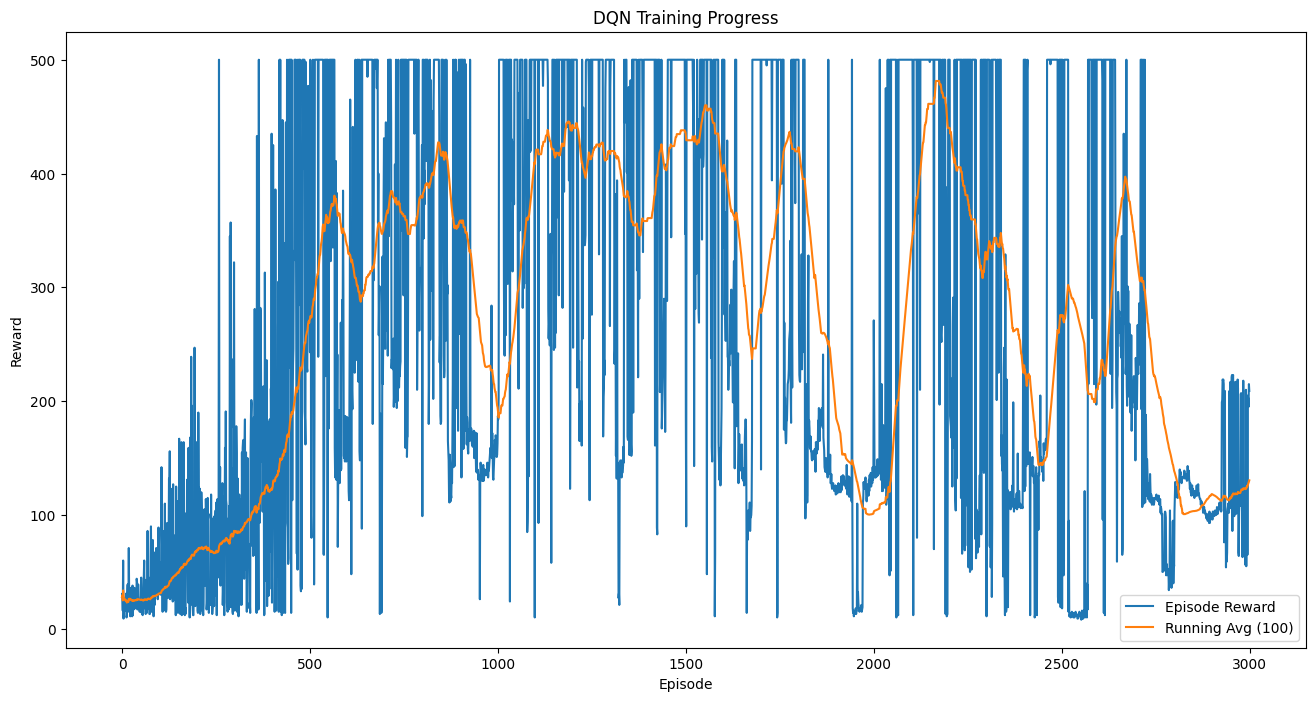

In [7]:
#Run DQN agent
agent = DQNAgent(env)
agent.train()

In [ ]:
# Run GPI algorithm
policy_iteration()

Comparing the results of our DQN agent and the GPI with TD and Epsilon-Greedy, the DQN agent outperforms the GPI agent significantly in terms of cumulative rewards and average rewards.

Some reasons for this may include:
1. DQN works better in continuous state spaces (such as Cart Velocity and Pole Velocity), whereas GPI requires discretization.
    - Inefficient discretization of state spaces into bins may result in misrepresentation of data
    - DQN generalizes better by learning representations of the state space
2. DQN uses experience replay and target networks to stabilize training, whereas the GPI agent we employed makes use of transition model
    - Experience replay and target networks make it effective in environments like CartPole, where continuous updates to the Q-values are required
    - GPI doesn't typically use a replay buffer. Instead, it updates values immediately after each interaction, which can lead to issues such as overfitting to recent experiences and instability if the state space is large or the policy changes frequently.

Hence, we decide to employ the DQN agent over the GPI agent for the below two tasks

## Task 2: Demonstrate the effectiveness of the RL agent

In [ ]:
agent.test()

## Task 3: Render one episode played by the developed RL agent on Jupyter

In [ ]:
agent2.render()